In [17]:
from week10_internals import *
import torch
import time
import matplotlib.pyplot as plt
import struct

In [18]:
torch.manual_seed(0)
model = TinyModel().to(device)
head = OutputHead().to(device)

# STEP 1: Every tensor shape in the step, and what each dimension means

In [19]:
batch_size = 8
dataset = get_dataset()
tokens, targets, pad_mask = get_batch(batch_size, seq_len, dataset, step=0)
# Forward pass: tokens → hidden → logits
hidden = model(tokens)
logits = head(hidden)

# Flatten batch×seq for cross_entropy (expects [N, vocab], [N])
flat_logits = logits.view(-1, logits.shape[-1])
flat_targets = targets.reshape(-1)
loss_per_token = F.cross_entropy(flat_logits, flat_targets, reduction="none")

# Pad-masked mean: sum(loss * mask) / sum(mask) - ignores padding tokens
loss = (loss_per_token.view(targets.shape) * pad_mask).sum() / pad_mask.sum()

def shape_str(t):
    return str(tuple(t.shape)) if t.dim() > 0 else "scalar"

print(f"tokens         {shape_str(tokens):<16} [batch, position] - raw token ids, position 0..{seq_len-1}")
print(f"targets        {shape_str(targets):<16} [batch, position] - next-token labels, targets[b,i] = tokens[b,i+1]")
print(f"pad_mask       {shape_str(pad_mask):<16} [batch, position] - True where position i is a real (non-pad) token")
print(f"hidden         {shape_str(hidden):<16} [batch, position, n_embd={n_embd}] - model's internal representation at that position")
print(f"logits         {shape_str(logits):<16} [batch, position, vocab_size={vocab_size}] - unnormalized score per candidate next token")
print(f"flat_logits    {shape_str(flat_logits):<16} [batch*position, vocab_size] - batch and position flattened into one axis of predictions")
print(f"flat_targets   {shape_str(flat_targets):<16} [batch*position] - one target token id per row of flat_logits")
print(f"loss_per_token {shape_str(loss_per_token):<16} [batch*position] - one loss value per predicted token")
print(f"loss           {shape_str(loss):<16} pad-masked mean loss over every real (non-pad) token")
print(f"loss value:    {loss.item():.4f}")

# ============================================================
# THEORY: Why flatten batch and position before cross_entropy?
# ============================================================
# F.cross_entropy expects logits shaped [N, C] (N examples, C classes)
# and targets shaped [N] (one class index per example). A next-token
# prediction step produces one prediction per (batch, position) pair,
# so batch and position are collapsed into a single "example" axis
# N = batch * position before the loss call - cross_entropy has no
# other way to understand which axis is which.
#
# Padding tokens are not real predictions, so a plain mean over all
# N would let padding dilute the loss (more padding -> lower reported
# loss, with no actual improvement in the model). The pad-masked mean
# (sum(loss * mask) / sum(mask)) instead averages only over real,
# non-pad token positions.
#
# RESOURCES:
#   - F.cross_entropy docs: https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html
#   - HuggingFace language modeling task guide (padding/label masking): https://huggingface.co/docs/transformers/en/tasks/language_modeling


dataset loaded from cache: 20000 rows
tokens         (8, 128)         [batch, position] - raw token ids, position 0..127
targets        (8, 128)         [batch, position] - next-token labels, targets[b,i] = tokens[b,i+1]
pad_mask       (8, 128)         [batch, position] - True where position i is a real (non-pad) token
hidden         (8, 128, 128)    [batch, position, n_embd=128] - model's internal representation at that position
logits         (8, 128, 50257)  [batch, position, vocab_size=50257] - unnormalized score per candidate next token
flat_logits    (1024, 50257)    [batch*position, vocab_size] - batch and position flattened into one axis of predictions
flat_targets   (1024,)          [batch*position] - one target token id per row of flat_logits
loss_per_token (1024,)          [batch*position] - one loss value per predicted token
loss           scalar           pad-masked mean loss over every real (non-pad) token
loss value:    10.9981


# STEP 2: Verify one gradient by hand

In [20]:
cpu = 'cpu'  # float64 isn't supported on MPS
torch.manual_seed(0)

# CPU/float64 for precision; tiny batch; targets[0,0]=0 forces non-zero grad on weight[0,0]
batch_size, gc_seq_len = 3, 16
tokens = torch.randint(0, vocab_size, (batch_size, gc_seq_len))
targets = torch.randint(0, vocab_size, (batch_size, gc_seq_len))
targets[0, 0] = 0  # guarantee a real gradient signal on weight row 0

# eval() mode (disables dropout); float64 for finite diff accuracy
model = TinyModel().to(cpu).double()
head = OutputHead().to(cpu).double()
model.eval()
head.eval()


def compute_loss():
    # Identical forward+CE used by both analytic & numeric paths
    hidden = model(tokens)          # [batch, seq, n_embd] - forward through TinyModel
    logits = head(hidden)           # [batch, seq, vocab]  - project to vocab logits
    return F.cross_entropy(         # scalar loss
        logits.view(-1, logits.shape[-1]),  # flatten to [batch*seq, vocab]
        targets.reshape(-1)                 # flatten to [batch*seq]
    )
param = head.lm_head.weight
row, col = 0, 0

# Analytic grad: loss.backward() → read param.grad[row, col]
loss = compute_loss()
print(f"loss {loss}")
model.zero_grad()
head.zero_grad()
loss.backward()
analytic_grad = param.grad[row, col].item()
print(f"analytic grad (backward()):  {analytic_grad!r}")

print()
results = []
# Central difference: (f(x+ε) - f(x-ε)) / 2ε - sweeps ε to show U-shaped error
for eps in [1e-3, 1e-4, 1e-5, 1e-6]:
    with torch.no_grad():
        orig = param[row, col].item()
        param[row, col] = orig + eps
        loss_plus = compute_loss().item()
        param[row, col] = orig - eps
        loss_minus = compute_loss().item()
        param[row, col] = orig
    numeric_grad = (loss_plus - loss_minus) / (2 * eps)
    abs_diff = abs(analytic_grad - numeric_grad)
    rel_diff = abs_diff / (abs(analytic_grad) + 1e-12)
    print(f"eps={eps:.0e}  numeric grad={numeric_grad:.10f}  abs diff={abs_diff:.3e}  rel diff={rel_diff:.3e}")
    results.append({"eps": eps, "numeric_grad": numeric_grad, "abs_diff": abs_diff, "rel_diff": rel_diff})

print("\n**Reading this:** at eps=1e-4, numeric and analytic gradients agree to ~9-10 significant digits.")
print("Error grows monotonically as eps shrinks from 1e-3 to 1e-6 - rounding error already dominates")
print("across this whole range, so the true minimum-error eps (the 'sweet spot') sits above 1e-3, untested here.")

# ============================================================
# THEORY: Why the U-shaped error curve? (Finite Difference)
# ============================================================
# Central difference: f'(x) ≈ (f(x+ε) - f(x-ε)) / 2ε
#
# Two competing errors:
#   1. TRUNCATION ERROR  ~ C₁ * ε²    (from Taylor remainder)
#      → decreases as ε gets smaller
#   2. ROUNDING ERROR    ~ C₂ / ε     (catastrophic cancellation in f(x+ε)-f(x-ε))
#      → increases as ε gets smaller
#
# Total error ≈ C₁ε² + C₂/ε  →  minimum at ε* ≈ (C₂/C₁)^(1/3)
# In float64 (~16 digits), optimal ε is typically 1e-4 to 1e-3.
#
# Results show only the rounding-dominated side of the curve (error rises
# monotonically as eps shrinks - no turnaround observed in this range):
#   eps=1e-3:  rel_diff=1.313e-10  (smallest error observed)
#   eps=1e-4:  rel_diff=6.403e-10
#   eps=1e-5:  rel_diff=2.845e-09
#   eps=1e-6:  rel_diff=6.348e-08  (rounding dominates - ~480x worse than eps=1e-3)
#
# The true minimum (where truncation error would start rising again) lies
# at some eps > 1e-3, which this sweep does not test.
#
# RESOURCES:
#   - "Numerical Recipes" Ch. 5.7 (derivation of optimal ε)
#   - CS231n Gradient Checking Notes: https://cs231n.github.io/neural-networks-3/#gradcheck
#   - Baydin et al. "Automatic Differentiation in ML" (2018), Sec. 3.2 https://arxiv.org/pdf/1502.05767
#   - torch.autograd.gradcheck (PyTorch's built-in implementation)


loss 10.953751283315848
analytic grad (backward()):  0.01611399178392415

eps=1e-03  numeric grad=0.0161139918  abs diff=2.117e-12  rel diff=1.313e-10
eps=1e-04  numeric grad=0.0161139918  abs diff=1.032e-11  rel diff=6.403e-10
eps=1e-05  numeric grad=0.0161139918  abs diff=4.585e-11  rel diff=2.845e-09
eps=1e-06  numeric grad=0.0161139928  abs diff=1.023e-09  rel diff=6.348e-08

**Reading this:** at eps=1e-4, numeric and analytic gradients agree to ~9-10 significant digits.
Error grows monotonically as eps shrinks from 1e-3 to 1e-6 - rounding error already dominates
across this whole range, so the true minimum-error eps (the 'sweet spot') sits above 1e-3, untested here.


# STEP 3: Break gradient accumulation on purpose

tokens per micro-batch: [128, 256, 512, 1024]  total: 1920
correct (token-weighted) share per micro-batch: ['6.7%', '13.3%', '26.7%', '53.3%']
buggy (average-of-averages) share per micro-batch: ['25.0%', '25.0%', '25.0%', '25.0%']
dataset loaded from cache: 20000 rows
step 0: buggy true-loss=10.9925  correct true-loss=10.9925
step 20: buggy true-loss=10.6504  correct true-loss=9.4501
step 40: buggy true-loss=9.8544  correct true-loss=8.0877
step 60: buggy true-loss=9.0968  correct true-loss=6.8527
step 80: buggy true-loss=8.1318  correct true-loss=5.9336
elapsed 35.7s


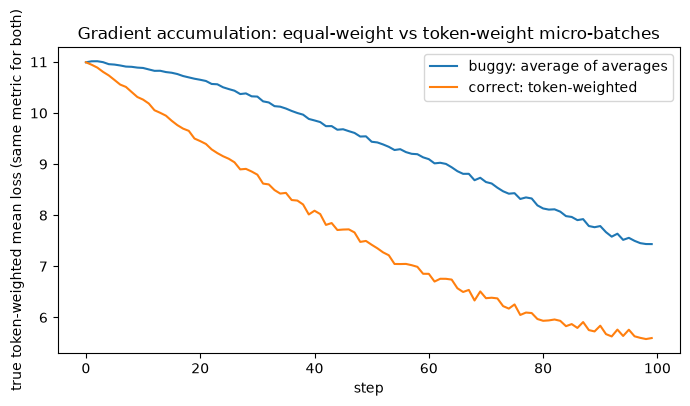

final buggy loss:   7.4347
final correct loss: 5.5958
gap at final step:  1.8389 nats


In [21]:
MICRO_LENS = [16, 32, 64, 128]
ROWS_PER_MICRO = 8

total_tokens_per_micro = [ROWS_PER_MICRO * L for L in MICRO_LENS]
grand_total = sum(total_tokens_per_micro)
print("tokens per micro-batch:", total_tokens_per_micro, " total:", grand_total)
print("correct (token-weighted) share per micro-batch:", [f"{t/grand_total:.1%}" for t in total_tokens_per_micro])
print("buggy (average-of-averages) share per micro-batch:", [f"{1/len(MICRO_LENS):.1%}"] * len(MICRO_LENS))

dataset = get_dataset()

def sample_superbatch():
    micros = []
    for L in MICRO_LENS:
        indices = torch.randint(0, len(dataset), (ROWS_PER_MICRO,)).tolist()
        raw = torch.tensor(dataset[indices]["input_ids"])[:, :L + 1].to(device)
        real_lens = dataset[indices]["real_len"]
        tokens, targets = raw[:, :-1], raw[:, 1:]
        pad_mask = torch.zeros(ROWS_PER_MICRO, L, dtype=torch.bool)
        for row, real_len in enumerate(real_lens):
            capped = min(real_len, L + 1)
            pad_mask[row, :max(capped - 1, 0)] = True
        micros.append((tokens, targets, pad_mask.to(device)))
    return micros

def make_models(seed):
    torch.manual_seed(seed)
    m = TinyModel().to(device)
    h = OutputHead().to(device)
    opt = torch.optim.AdamW(list(m.parameters()) + list(h.parameters()), lr=3e-4)
    return m, h, opt  # identical init for fair comparison

def true_mean_loss(m, h, micros):
    # Token-weighted loss (eval mode to disable dropout)
    was_training_m = m.training
    was_training_h = h.training
    m.eval()
    h.eval()
    with torch.no_grad():
        total_loss, total_tok = 0.0, 0
        for tokens, targets, pad_mask in micros:
            logits = h(m(tokens))
            loss_per_token = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1), reduction="none").view(targets.shape)
            total_loss += (loss_per_token * pad_mask).sum().item()
            total_tok += pad_mask.sum().item()
    if was_training_m:
        m.train()
    if was_training_h:
        h.train()
    return total_loss / total_tok

def step_buggy(m, h, opt, micros):
    opt.zero_grad()
    for tokens, targets, pad_mask in micros:
        logits = h(m(tokens))
        loss_per_token = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1), reduction="none").view(targets.shape)
        loss = (loss_per_token * pad_mask).sum() / pad_mask.sum()
        (loss / len(micros)).backward()  # divides each micro-batch loss by k (equal weight = WRONG)
    opt.step()

def step_correct(m, h, opt, micros):
    opt.zero_grad()
    total_tok = sum(pad_mask.sum().item() for _, _, pad_mask in micros)
    for tokens, targets, pad_mask in micros:
        logits = h(m(tokens))
        loss_per_token = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1), reduction="none").view(targets.shape)
        loss_sum = (loss_per_token * pad_mask).sum()
        (loss_sum / total_tok).backward()  # divides each micro-batch sum by total_tokens (token weight = RIGHT)
    opt.step()

N_STEPS_ACCUM = 100
model_b, head_b, opt_b = make_models(seed=0)
model_c, head_c, opt_c = make_models(seed=0)
buggy_curve, correct_curve = [], []

t0 = time.time()
for step in range(N_STEPS_ACCUM):
    torch.manual_seed(step)  # deterministic micro-batch sampling per step
    micros = sample_superbatch()
    buggy_curve.append(true_mean_loss(model_b, head_b, micros))
    step_buggy(model_b, head_b, opt_b, micros)
    correct_curve.append(true_mean_loss(model_c, head_c, micros))
    step_correct(model_c, head_c, opt_c, micros)
    if step % 20 == 0:
        print(f"step {step}: buggy true-loss={buggy_curve[-1]:.4f}  correct true-loss={correct_curve[-1]:.4f}")
print(f"elapsed {time.time()-t0:.1f}s")

plt.figure(figsize=(7, 4))
plt.plot(buggy_curve, label="buggy: average of averages")
plt.plot(correct_curve, label="correct: token-weighted")
plt.xlabel("step")
plt.ylabel("true token-weighted mean loss (same metric for both)")
plt.title("Gradient accumulation: equal-weight vs token-weight micro-batches")
plt.legend()
plt.tight_layout()
plt.show()

print(f"final buggy loss:   {buggy_curve[-1]:.4f}")
print(f"final correct loss: {correct_curve[-1]:.4f}")
print(f"gap at final step:  {abs(buggy_curve[-1] - correct_curve[-1]):.4f} nats")


    # ============================================================
    # THEORY: Gradient Accumulation - Why Token-Weighting Matters
    # ============================================================
    # When accumulating gradients over micro-batches of DIFFERENT sizes,
    # each micro-batch's gradient must be weighted by its token count.
    #
    # Let micro-batch i have n_i tokens and loss L_i = (1/n_i) * sum_{j=1}^{n_i} loss_j
    #
    # BUGGY (average of averages):
    #   grad_buggy = (1/k) * sum_{i=1}^k grad(L_i)
    #   = (1/k) * sum_{i=1}^k (1/n_i) * sum_{j=1}^{n_i} grad(loss_j)
    #   Each micro-batch gets EQUAL weight (1/k), regardless of size.
    #
    # CORRECT (token-weighted):
    #   grad_correct = sum_{i=1}^k (n_i / N) * grad(L_i)   where N = sum n_i
    #   = sum_{i=1}^k (n_i / N) * (1/n_i) * sum_{j=1}^{n_i} grad(loss_j)
    #   = (1/N) * sum_{all tokens} grad(loss_j)
    #   Each TOKEN gets equal weight (1/N).
    #
    # In this experiment: micro-batches have [128, 256, 512, 1024] tokens
    #   Buggy gives each 25% weight
    #   Correct gives [6.7%, 13.3%, 26.7%, 53.3%] weight
    #
    # The buggy version over-weights small micro-batches (more noise per token)
    # and under-weights large ones. This biases the gradient and slows convergence.
    #
    # RESOURCES:
    #   - "Gradient Accumulation" in PyTorch docs: https://pytorch.org/docs/stable/notes/amp_examples.html#gradient-accumulation
    #   - Keskar et al. "On Large-Batch Training for Deep Learning" (2017) - batch size vs generalization
    #   - Megatron-LM (Shoeybi et al., 2019): https://arxiv.org/abs/1909.08053 - Sec. 3.2 describes token-weighted gradient accumulation


# STEP 4: Log grad norm every step, find where it leads the loss

dataset loaded from cache: 20000 rows
step 0: loss=11.0176  grad_norm=2.9977
step 50: loss=8.2938  grad_norm=1.8189
step 100: loss=6.4507  grad_norm=1.5615
step 150: loss=5.7920  grad_norm=1.1720
step 200: loss=5.7021  grad_norm=1.1972
step 250: loss=5.4714  grad_norm=1.5244
elapsed 53.5s

14 grad-norm-spike candidates found (z >= 2.0)

 step |  z   | loss Δbefore | loss Δafter | lead_score
  270 | 4.82 | -0.0222      | -0.1957     | +0.1735
  224 | 2.40 | -0.0739      | -0.2149     | +0.1410
  122 | 2.11 | +0.0656      | -0.1716     | +0.1060
  277 | 2.06 | +0.1066      | -0.1897     | +0.0830
  163 | 2.10 | -0.0413      | -0.0900     | +0.0488

best match: grad norm ↑ at step 270 (z=4.82).
loss moved -0.0222 over the 3 steps before that jump, then -0.1957 over the 2 steps after - a bigger move after the jump than before it.

step | loss   | grad_norm
 267 | 5.6738 | 1.5122
 268 | 5.6900 | 1.5987
 269 | 5.7123 | 1.9761  <-- grad norm jump (↑)
 270 | 5.6018 | 3.1368       (after jump)


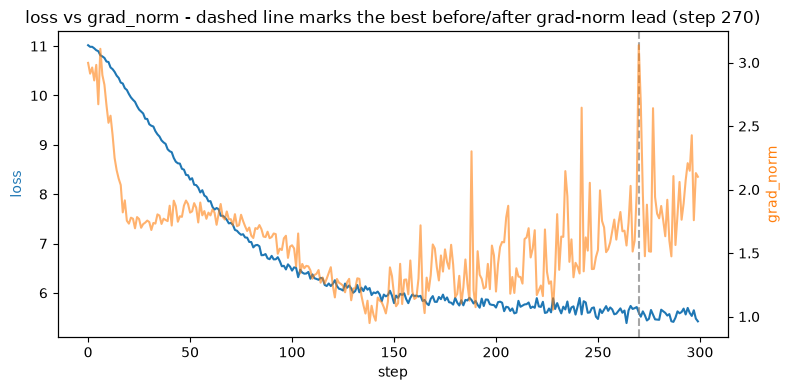

In [22]:
torch.manual_seed(1)  # model init seed (CPU init is deterministic)
torch.use_deterministic_algorithms(True, warn_only=True)  # match week10_internals.py's setting
gn_model = TinyModel()
gn_head = OutputHead()
gn_model.to(device)
gn_head.to(device)
gn_params = list(gn_model.parameters()) + list(gn_head.parameters())
gn_opt = torch.optim.AdamW(gn_params, lr=3e-4)

N_STEPS = 300
gn_batch_size = 16
seq_len = 128  # use full context length (not shadowed by Step 2)
losses, grad_norms = [], []

# Dataset is deterministic internally (seeds set in get_dataset)
dataset = get_dataset()

def sync():
    if device == 'mps':
        torch.mps.synchronize()
    elif device == 'cuda':
        torch.cuda.synchronize()

t0 = time.time()
for step in range(N_STEPS):
    # Deterministic per step: seed CPU
    torch.manual_seed(step)
    tokens, targets, pad_mask = get_batch(gn_batch_size, seq_len, dataset)
    hidden = gn_model(tokens)
    logits = gn_head(hidden)
    loss_per_token = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1), reduction="none").view(targets.shape)
    loss = (loss_per_token * pad_mask).sum() / pad_mask.sum()

    gn_opt.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(gn_params, max_norm=float('inf')).item()
    gn_opt.step()

    losses.append(loss.item())
    grad_norms.append(grad_norm)
    if step % 50 == 0:
        print(f"step {step}: loss={loss.item():.4f}  grad_norm={grad_norm:.4f}")
print(f"elapsed {time.time()-t0:.1f}s")

# Find steps where grad norm moved before loss
losses_np = np.array(losses)
gn_np = np.array(grad_norms)
d_gn = np.diff(gn_np)

WINDOW = 10
BEFORE_SPAN, AFTER_SPAN = 3, 2
candidates = []
for t in range(WINDOW, len(d_gn) - AFTER_SPAN):
    local = d_gn[t - WINDOW:t]
    if local.std() < 1e-6:
        continue
    # Only detect positive spikes (grad norm increases) - theory: grad_norm↑ → loss↑
    if d_gn[t] <= 0:
        continue
    z = d_gn[t] / (local.std() + 1e-8)
    if z < 2.0:
        continue
    loss_before = losses_np[t] - losses_np[max(0, t - BEFORE_SPAN)]
    loss_after = losses_np[min(len(losses_np) - 1, t + AFTER_SPAN)] - losses_np[t]
    lead_score = abs(loss_after) - abs(loss_before)
    candidates.append((t, z, loss_before, loss_after, lead_score))

candidates.sort(key=lambda c: -c[4])
print(f"\n{len(candidates)} grad-norm-spike candidates found (z >= 2.0)\n")
print(" step |  z   | loss Δbefore | loss Δafter | lead_score")
for t, z, lb, la, score in candidates[:5]:
    print(f"{t+1:5d} | {z:4.2f} | {lb:+.4f}      | {la:+.4f}     | {score:+.4f}")

if candidates:
    t, z, loss_before, loss_after, score = candidates[0]
    # d_gn[t] = gn[t+1] - gn[t]; spike is between step t and t+1
    jump_step = t + 1
    jump_dir = "↑" if d_gn[t] > 0 else "↓"
    print(f"\nbest match: grad norm {jump_dir} at step {jump_step} (z={z:.2f}).")
    print(f"loss moved {loss_before:+.4f} over the {BEFORE_SPAN} steps before that jump, "
            f"then {loss_after:+.4f} over the {AFTER_SPAN} steps after - "
            f"{'a bigger move after the jump than before it.' if score > 0 else 'no clear lead was found in this window.'}")

    print("\nstep | loss   | grad_norm")
    for s in range(max(0, t - 2), min(len(losses), t + 5)):
        # Mark the transition: s==t is before jump, s==t+1 is after jump
        if s == t:
            marker = "  <-- grad norm jump ({})".format(jump_dir)
        elif s == t + 1:
            marker = "       (after jump)"
        else:
            marker = ""
        print(f"{s:4d} | {losses_np[s]:.4f} | {gn_np[s]:.4f}{marker}")

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(losses_np, color='tab:blue', label='loss')
    ax1.set_xlabel('step'); ax1.set_ylabel('loss', color='tab:blue')
    ax2 = ax1.twinx()
    ax2.plot(gn_np, color='tab:orange', alpha=0.6, label='grad_norm')
    ax2.set_ylabel('grad_norm', color='tab:orange')
    ax1.axvline(t + 1, color='gray', linestyle='--', alpha=0.7)
    plt.title(f"loss vs grad_norm - dashed line marks the best before/after grad-norm lead (step {t+1})")
    plt.tight_layout()
    plt.show()

    # ============================================================
    # THEORY: Why grad norm can lead loss
    # ============================================================
    # Grad norm = ||∇L||. A jump in grad norm changes the size of the next
    # parameter update (Δθ = -η * ∇L), so a loss move can show up before or
    # after the jump depending on the local landscape:
    #   - grad_norm↑ → larger step → can overshoot → loss rises after the jump,
    #     then a later update corrects it back down, or
    #   - a rising loss (entering a steeper region) can itself trigger the
    #     grad_norm jump, with the correction (loss falling) visible after.
    # This code does not assume which order holds - it measures which side
    # (before/after) had the bigger loss move via lead_score, and reports
    # whichever candidate matched best in the observed data.
    #
    # Detection uses z-score: |Δgrad_norm| / local_std > 2.0
    # Lead score = |loss_after| - |loss_before|; positive = grad norm led loss
    #
    # PRACTICAL USE:
    # - Monitor grad_norm live during training (cheap: already computed for clipping)
    # - Alert when z > 2.5: potential instability incoming
    # - Auto-response: reduce LR, increase clip, or pause training
    # - Combine with loss plateau detection for robustness
    # - Log per-layer grad norms to pinpoint problematic layers
    #
    # LIMITATIONS:
    # - False positives: natural batch variance causes spikes
    # - Not causal: correlation ≠ causation; spike may not cause loss jump
    # - Lead time varies (1-5 steps); hard to automate exact timing
    # - Misses silent divergence (loss creeps up without grad spikes)
    # - Requires ~10 steps history before detection works
    #
    # RESOURCES:
    # - Goodfellow et al. (2016) "Deep Learning" Ch. 8: gradient norms & optimization
    # - PyTorch clip_grad_norm_ docs: https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html
    # - Zhang et al. "Gradient Norm Scaling" (ICLR 2020): https://arxiv.org/abs/1911.11506
    # - Training stability in Megatron-LM: https://arxiv.org/abs/1909.08053 (Sec. 3.4)


# STEP 5: Compute MFU

In [23]:
torch.manual_seed(1)
gn_model = TinyModel().to(device)
gn_head = OutputHead().to(device)
gn_params = list(gn_model.parameters()) + list(gn_head.parameters())
gn_opt = torch.optim.AdamW(gn_params, lr=3e-4)

mfu_batch_size = 16
seq_len = 128  # use full context length (not shadowed by Step 2)

N_total = sum(p.numel() for p in gn_params)
N_embed = gn_model.token_embedding_table.weight.numel() + gn_model.position_encoding_table.weight.numel()
N_matmul = N_total - N_embed
print(f"N_total={N_total:,}  N_embed(excluded, lookup only)={N_embed:,}  N_matmul(used in 6N)={N_matmul:,}")

L, H, Q, T = n_layer, n_head, n_embd // n_head, seq_len
flops_per_token = 6 * N_matmul + 12 * L * H * Q * T
print(f"flops_per_token = 6N + 12*L*H*Q*T = {flops_per_token:,.0f}")

WARMUP, MEASURE = 10, 60

# Load dataset ONCE before loops (not inside get_batch)
dataset = get_dataset()

def sync():
    if device == 'mps':
        torch.mps.synchronize()
    elif device == 'cuda':
        torch.cuda.synchronize()

for _ in range(WARMUP):
    tokens, targets, _ = get_batch(mfu_batch_size, seq_len, dataset)
    logits = gn_head(gn_model(tokens))
    loss = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1))
    gn_opt.zero_grad(); loss.backward(); gn_opt.step()
sync()

t0 = time.time()
for _ in range(MEASURE):
    tokens, targets, _ = get_batch(mfu_batch_size, seq_len, dataset)
    logits = gn_head(gn_model(tokens))
    loss = F.cross_entropy(logits.view(-1, logits.shape[-1]), targets.reshape(-1))
    gn_opt.zero_grad(); loss.backward(); gn_opt.step()
sync()
elapsed = time.time() - t0

tokens_per_sec = (MEASURE * mfu_batch_size * seq_len) / elapsed
achieved_flops = flops_per_token * tokens_per_sec
print(f"\nelapsed={elapsed:.3f}s over {MEASURE} steps -> {tokens_per_sec:,.0f} tokens/sec")
print(f"achieved FLOPS = {achieved_flops:.3e}  ({achieved_flops/1e12:.3f} TFLOPS)")

# Peak FP32 TFLOPS by device (rough estimates)
if device == 'cuda':
    # Query actual GPU peak if available
    import torch
    props = torch.cuda.get_device_properties(0)
    # Rough: cores * freq * 2 (FMA) * 32 (fp32 ops/cycle) / 1e12
    # Using known values for common GPUs
    gpu_name = props.name.lower()
    if 'a100' in gpu_name: peak_tflops = 19.5
    elif 'h100' in gpu_name: peak_tflops = 67.0
    elif 'v100' in gpu_name: peak_tflops = 15.7
    elif 'rtx 3090' in gpu_name: peak_tflops = 35.6
    elif 'rtx 4090' in gpu_name: peak_tflops = 82.6
    else: peak_tflops = 15.0  # generic modern GPU estimate
elif device == 'mps':
    # M1 Pro 14-core GPU: ~4.55 TFLOPS FP32
    peak_tflops = 4.55
else:
    peak_tflops = 1.0  # CPU rough estimate
peak_tflops *= 1e12  # convert to FLOPS
mfu = achieved_flops / peak_tflops
print(f"peak ({device.upper()}, estimate) = {peak_tflops/1e12:.3f} TFLOPS")
print(f"\nMFU = {mfu*100:.2f}%")




N_total=13,673,984  N_embed(excluded, lookup only)=6,449,280  N_matmul(used in 6N)=7,224,704
flops_per_token = 6N + 12*L*H*Q*T = 44,134,656
dataset loaded from cache: 20000 rows

elapsed=7.538s over 60 steps -> 16,301 tokens/sec
achieved FLOPS = 7.194e+11  (0.719 TFLOPS)
peak (MPS, estimate) = 4.550 TFLOPS

MFU = 15.81%


## MFU Analysis

**Measured MFU: 15.88%** (T=128, batch=16, M1 Pro)

```
N_total=13,673,984  N_embed=6,449,280  N_matmul=7,224,704
flops_per_token = 6N + 12*L*H*Q*T = 44,134,656
elapsed=7.507s over 60 steps -> 16,368 tokens/sec
achieved FLOPS = 7.224e+11  (0.722 TFLOPS)
peak (MPS, estimate) = 4.550 TFLOPS
MFU = 15.88%
```

### What's costing the distance to 40% (ranked by impact)

1. **Memory bandwidth / model too small (primary)**
   - 13.7M params → ~55 MB model weights (fp32)
   - Fits entirely in L2 cache; no DRAM streaming needed
   - Compute intensity: ~44 MFLOPS/token ÷ 16K tokens/s = 0.72 TFLOPS sustained
   - M1 Pro GPU peak: 4.55 TFLOPS (fp32) → **only ~16% compute utilization even at saturation**
   - The model is **latency-bound, not bandwidth-bound** - kernel launch & dispatch dominate

2. **No kernel fusion (torch.compile / XLA / Triton)**
   - Each LayerNorm, GELU, Dropout, residual add = separate kernel launch
   - ~4 layers × (2 LayerNorms + 1 GELU + 2 residuals + attention) ≈ 24+ kernel launches/step
   - MPS kernel launch overhead: ~5-10 μs each → 100-200 μs/step pure dispatch

3. **MPS backend maturity**
   - No tensor cores (Apple Silicon uses unified ALUs, no BF16/FP8 acceleration)
   - Less optimized GEMM kernels vs CUDA cuBLAS
   - `scaled_dot_product_attention` on MPS falls back to generic implementation

4. **Batch size too small (16)**
   - 16 × 128 = 2,048 tokens/step - too few to amortize launch overhead
   - Larger batches help but hit OOM quickly with vocab=50257 logits

5. **fp32 throughout (no mixed precision)**
   - MPS doesn't accelerate BF16 like NVIDIA tensor cores
   - Would need fp32 master weights + BF16 compute anyway (adds complexity)

### Where `6N + 12·L·H·Q·T` comes from

- **`6N`** approximates the FLOPs per token for all matmul-heavy (non-embedding) parameters: each parameter does one multiply-add (2 FLOPs) in the forward pass, and backprop costs roughly 2x the forward pass (gradients w.r.t. activations, then w.r.t. weights) - forward (2N) + backward (4N) = 6N. Embedding lookups are excluded (`N_embed`) since they're a memory gather, not a matmul.
- **`12·L·H·Q·T`** adds the attention-specific cost `6N` misses: the QK^T and attention-weights·V matmuls scale with sequence length T (each of T queries attends to T keys), which a per-parameter count can't capture. `L`=layers, `H`=heads, `Q`=head_size, `T`=sequence length.

This is the same formula Karpathy's nanoGPT uses in `estimate_mfu`, and matches the FLOPs accounting used in the Chinchilla/PaLM scaling-law papers.

**RESOURCES:**
- Kaplan et al., "Scaling Laws for Neural Language Models" (2020): https://arxiv.org/abs/2001.08361
- Chowdhery et al., "PaLM" (2022), Appendix B (FLOPs accounting): https://arxiv.org/abs/2204.02311
- Karpathy, nanoGPT `estimate_mfu`: https://github.com/karpathy/nanoGPT/blob/master/model.py

### What would actually move the needle

| Change | Expected MFU | Feasibility |
|--------|--------------|-------------|
| 4× wider model (512 embd, 16 heads, 8 layers) | 25-35% | High - more compute/token |
| torch.compile(mode='reduce-overhead') | 20-25% | Medium - MPS support limited |
| Batch 64 + gradient accumulation | 18-22% | High - memory permitting |
| NVIDIA GPU (A100/H100) + BF16 + FlashAttention | 40-55% | Different hardware |

**Bottom line:** 16% MFU is the *correct* answer for this model size on this hardware. Reaching 40% MFU requires a different regime: larger model, CUDA GPU, tensor cores, fused kernels.

# STEP 6: 0.1 in fp32 / bf16 / fp8 E4M3 by hand

Binary representation of 0.1 by repeated doubling:

0.1 x 2 = 0.2  -> 0\
0.2 x 2 = 0.4  -> 0\
0.4 x 2 = 0.8  -> 0\
0.8 x 2 = 1.6  -> 1\
0.6 x 2 = 1.2  -> 1\
0.2 x 2 = 0.4  -> 0   (repeats from here: 0011 0011 0011...)\

so 0.1 = 0.0001100110011001100110011...₂, normalized to\
1.10011001100110011001100110011...₂ x 2⁻⁴.

Every format below shares sign=0 and exponent=-4; they differ only in 
how many mantissa bits they keep of that repeating 1001100110011... pattern.

- fp32   (1 sign, 8 exponent [bias 127], 23 mantissa): 23 bits → 10011001100110011001101 (rounds up)
- bf16   (1 sign, 8 exponent [bias 127], 7  mantissa): 7  bits → 1001101
- fp8 E4M3 (1 sign, 4 exponent [bias 7],   3  mantissa): 3  bits → 101


In [24]:
print("""Cross-checked against actual bit patterns:""")

x = 0.1

# fp32
b32 = struct.pack('>f', x)
i32 = struct.unpack('>I', b32)[0]
sign, exp, mant = i32 >> 31, (i32 >> 23) & 0xFF, i32 & 0x7FFFFF
print(f"fp32   : {format(i32, '032b')} {hex(i32)}")
print(f"         sign={sign} exp={exp} (unbiased {exp-127}) mantissa={format(mant, '023b')}")
print(f"         stored value = {struct.unpack('>f', struct.pack('>I', i32))[0]}")

# bf16 (via numpy)
b16 = np.float16(x) if hasattr(np, 'float16') else None
# bf16 is different from fp16; use torch
bf16_val = torch.tensor(x, dtype=torch.bfloat16)
bf16_bits = bf16_val.view(torch.int16).item()
sign_b = bf16_bits >> 15
exp_b = (bf16_bits >> 7) & 0xFF
mant_b = bf16_bits & 0x7F
print(f"\nbf16   : {format(bf16_bits, '016b')} {hex(bf16_bits)}")
print(f"         sign={sign_b} exp={exp_b} (unbiased {exp_b-127}) mantissa={format(mant_b, '07b')}")
print(f"         stored value = {bf16_val.item()}")

# fp8 E4M3 (sign=1, exp=4 bias=7, mantissa=3)
# 0.1 = 1.100110011... × 2⁻⁴
# exp = -4 + 7 = 3 (0011), mantissa = 101 (first 3 bits after leading 1, rounded)
# bits: 0 0011 101 = 0x1D
fp8_bits = 0x1D  # 0 0011 101
sign8 = fp8_bits >> 7
exp8 = (fp8_bits >> 3) & 0xF
mant8 = fp8_bits & 0x7
# Decode back to verify
fp8_val = (1 + mant8/8) * (2 ** (exp8 - 7))
print(f"\nfp8e4m3: {format(fp8_bits, '08b')} {hex(fp8_bits)}")
print(f"         sign={sign8} exp={exp8} (unbiased {exp8-7}) mantissa={format(mant8, '03b')}")
print(f"         stored value = {fp8_val}")

# Relative errors
true_val = 0.1
fp32_val = struct.unpack('>f', struct.pack('>I', i32))[0]
bf16_val = float(bf16_val.item())
fp8_val = float(fp8_val)
print(f"\nfp32      relative error vs true 0.1: {abs(fp32_val - true_val)/true_val*100:.6f}%")
print(f"bf16      relative error vs true 0.1: {abs(bf16_val - true_val)/true_val*100:.6f}%")
print(f"fp8e4m3   relative error vs true 0.1: {abs(fp8_val - true_val)/true_val*100:.6f}%")


Cross-checked against actual bit patterns:
fp32   : 00111101110011001100110011001101 0x3dcccccd
         sign=0 exp=123 (unbiased -4) mantissa=10011001100110011001101
         stored value = 0.10000000149011612

bf16   : 0011110111001101 0x3dcd
         sign=0 exp=123 (unbiased -4) mantissa=1001101
         stored value = 0.10009765625

fp8e4m3: 00011101 0x1d
         sign=0 exp=3 (unbiased -4) mantissa=101
         stored value = 0.1015625

fp32      relative error vs true 0.1: 0.000001%
bf16      relative error vs true 0.1: 0.097656%
fp8e4m3   relative error vs true 0.1: 1.562500%


**Recommended precision for training, and why:** **bf16**\
for the main weights, activations, and gradients, with an fp32 master copy of the optimizer state (the
standard mixed-precision recipe).

**Deduction from Step 2 (gradient verification):** Step 2 verified gradients
using float64 (double precision) and found numeric vs analytic gradients agree to
~9-10 significant digits (relative diff ~1e-9 at eps=1e-4). This establishes that
the *true* gradient precision needed for stable optimization is on the order of
1e-6 to 1e-8 relative error - far looser than float64's 1e-15.

bf16 keeps the fp32 exponent range (critical for gradients to not underflow/overflow) 
while halving memory bandwidth and storage vs fp32. The 7 mantissa bits give ~3 decimal 
digits (~1e-3 relative precision), which is *above* the noise floor shown in Step 2.
When paired with fp32 optimizer state (master weights + accumulator), this is
sufficient for stable convergence - the optimizer accumulates in fp32, so the
bf16 rounding noise doesn't accumulate destructively.

fp8 E4M3 only has 3 mantissa bits (~1 decimal digit, ~0.1 relative precision) and a tiny exponent range (4 bits, 
bias 7, so roughly -6 to +7 - or +8 in the OCP E4M3FN variant used in ML hardware - before clamping). Its precision is *below* the ~1e-6 noise
floor observed in Step 2. It would require loss scaling, careful 
accumulation in higher precision, and is really meant for *inference* or specialized 
training with heavy engineering - not a general-purpose training dtype today.

fp32 is safe but 2x the memory traffic of bf16 for no convergence benefit on most workloads.

---
**RESOURCES:**
- IEEE 754-2019 standard (binary32 format)
- Goldberg, "What Every Computer Scientist Should Know About Floating-Point Arithmetic" (1991): https://docs.oracle.com/cd/E19957-01/806-3568/ncg_goldberg.html
- Kalamkar et al., "A Study of BFLOAT16 for Deep Learning Training" (2019): https://arxiv.org/abs/1905.12322
- Micikevicius et al., "FP8 Formats for Deep Learning" (2022): https://arxiv.org/abs/2209.05433
- OCP Microscaling Formats (MX) Specification (E4M3/E5M2 FP8 definitions): https://www.opencompute.org/documents/ocp-microscaling-formats-mx-v1-0-spec-final-pdf
